In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# =========================
# CONFIGURACIÓN GENERAL
# =========================

ruta_dataset = "dataset_limpio"
ruta_modelos = "Modelos"
ruta_tests = "tests"

IMG_SIZE = 32
tamanio_img = (IMG_SIZE, IMG_SIZE)
tamanio_lote = 32
seed = 123
epochs = 20

modelo_path = os.path.join(ruta_modelos, "animales5.keras")
clases_path = os.path.join(ruta_modelos, "clases_animales.json")

os.makedirs(ruta_modelos, exist_ok=True)
os.makedirs(ruta_tests, exist_ok=True)

print("Dataset:", os.path.abspath(ruta_dataset))
print("Modelo se guardará en:", os.path.abspath(modelo_path))
print("Carpeta de pruebas externas:", os.path.abspath(ruta_tests))

Dataset: c:\Users\Fernando\OneDrive\Escritorio\VsCode Proyects\dataset_limpio
Modelo se guardará en: c:\Users\Fernando\OneDrive\Escritorio\VsCode Proyects\Modelos\animales5.keras
Carpeta de pruebas externas: c:\Users\Fernando\OneDrive\Escritorio\VsCode Proyects\tests


In [3]:
# =========================
# VALIDAR DATASET
# =========================

extensiones_validas = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")

if not os.path.exists(ruta_dataset):
    raise FileNotFoundError(f"No existe la carpeta del dataset: {ruta_dataset}")

print("--- Revisión de carpetas ---")
for carpeta in sorted(os.listdir(ruta_dataset)):
    ruta_carpeta = os.path.join(ruta_dataset, carpeta)
    if os.path.isdir(ruta_carpeta):
        cantidad = sum(
            archivo.lower().endswith(extensiones_validas)
            for archivo in os.listdir(ruta_carpeta)
        )
        print(f"{carpeta}: {cantidad} imágenes")

--- Revisión de carpetas ---
Aranas: 8096 imágenes
Ballenas: 8114 imágenes
Changos: 8173 imágenes
Pajaros: 8126 imágenes
Ranas: 8120 imágenes


## Cargar dataset automáticamente

In [4]:
# =========================
# CARGAR DATASET
# =========================
# Divide automáticamente el dataset:
# 80% entrenamiento
# 20% validación/prueba interna

print("--- CARGANDO DATOS ---")

train_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_dataset,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=tamanio_img,
    batch_size=tamanio_lote,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_dataset,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=tamanio_img,
    batch_size=tamanio_lote,
    shuffle=False
)

clases = train_ds.class_names
n_clases = len(clases)

print("\nClases detectadas automáticamente:")
for i, clase in enumerate(clases):
    print(i, "=", clase)

--- CARGANDO DATOS ---
Found 40629 files belonging to 5 classes.
Using 32504 files for training.
Found 40629 files belonging to 5 classes.
Using 8125 files for validation.

Clases detectadas automáticamente:
0 = Aranas
1 = Ballenas
2 = Changos
3 = Pajaros
4 = Ranas


In [5]:
# =========================
# OPTIMIZACIÓN DE CARGA
# =========================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=seed).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Visualizar ejemplos del dataset

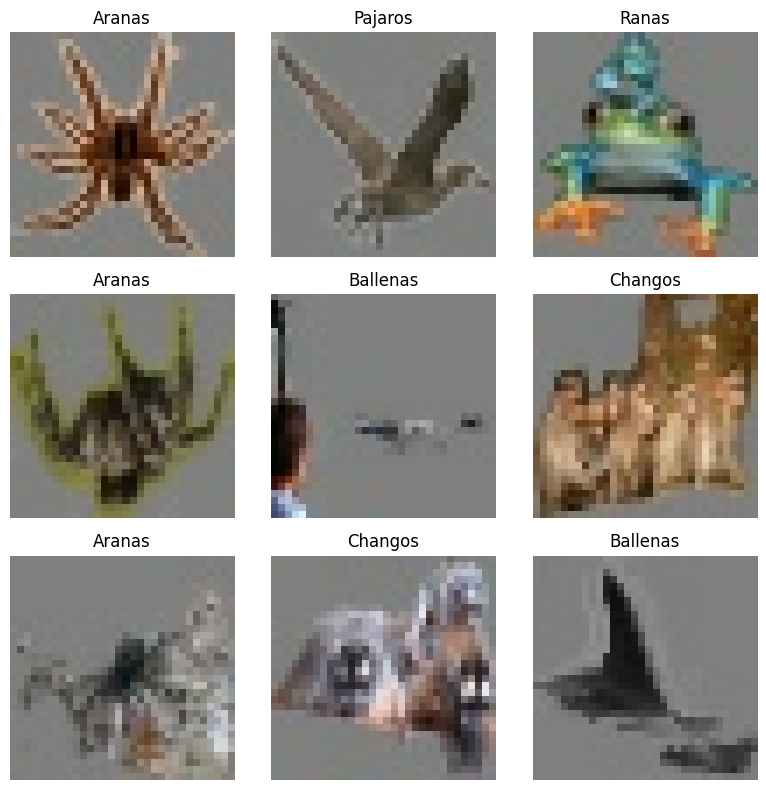

In [6]:
plt.figure(figsize=(8, 8))

for imagenes, etiquetas in train_ds.take(1):
    for i in range(min(9, len(imagenes))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(imagenes[i].numpy().astype("uint8"))
        plt.title(clases[int(etiquetas[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Construir modelo CNN

In [7]:
# =========================
# DATA AUGMENTATION
# =========================
# Se aplica solo durante el entrenamiento.

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [8]:
# =========================
# MODELO CNN 32x32
# =========================
# OJO: La normalización está dentro del modelo con Rescaling(1./255).
# Por eso las imágenes externas NO deben dividirse manualmente entre 255.
# =========================
# Con input tenemos 13 capas, sin el imput tenemos 12 capas.
# Bloque 1: Entrada y preparación de la imagen (Input, Data, Reescaling)
# Bloque 2: Extracción de características visuales (Conv2D(32), MaxPooling2D, Conv2D(64), MaxPooling2D, Conv2D(128), MaxPooling2D)
# Bloque 3: Clasificación (Flatten, Dense(128), Dropout(0.5), Dense(n_clases))


modelo = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(n_clases, activation="softmax")
])

modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,165 (1.36 MB)

 Trainable params: 356,165 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenar modelo

In [9]:
# =========================
# ENTRENAMIENTO
# =========================

print("--- INICIANDO ENTRENAMIENTO ---")

historial = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print("Entrenamiento finalizado.")

--- INICIANDO ENTRENAMIENTO ---
Epoch 1/20


1016/1016 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.5494 - loss: 1.1073 - val_accuracy: 0.9227 - val_loss: 0.4327
Epoch 2/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - accuracy: 0.6448 - loss: 0.9116 - val_accuracy: 0.8832 - val_loss: 0.3819
Epoch 3/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.6852 - loss: 0.8236 - val_accuracy: 0.6700 - val_loss: 0.8285
Epoch 4/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.7140 - loss: 0.7661 - val_accuracy: 0.8617 - val_loss: 0.4326
Epoch 5/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.7311 - loss: 0.7269 - val_accuracy: 0.8484 - val_loss: 0.4569
Epoch 6/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.7432 - loss: 0.6946 - val_accuracy: 0.8389 - val_loss: 0.4328
Epoch 7/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.7514 - loss: 0.6716 - val_accuracy: 0.7930 - val_loss: 0.5162
Epoch 8/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.7606 - loss: 0.65

## Guardar modelo y orden real de clases

In [10]:
# =========================
# GUARDAR MODELO Y CLASES
# =========================

modelo.save(modelo_path)

with open(clases_path, "w", encoding="utf-8") as f:
    json.dump(clases, f, ensure_ascii=False, indent=4)

print("Modelo guardado en:", modelo_path)
print("Clases guardadas en:", clases_path)
print("Clases:", clases)

Modelo guardado en: Modelos\animales5.keras
Clases guardadas en: Modelos\clases_animales.json
Clases: ['Aranas', 'Ballenas', 'Changos', 'Pajaros', 'Ranas']


## Evaluar modelo con validación interna

In [11]:
# =========================
# EVALUACIÓN INTERNA
# =========================

test_loss, test_acc = modelo.evaluate(val_ds, verbose=1)

print("Validation/Test loss:", test_loss)
print("Validation/Test accuracy:", test_acc)

  1/254 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8125 - loss: 0.4083

254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8870 - loss: 0.3385
Validation/Test loss: 0.3385447859764099
Validation/Test accuracy: 0.8870154023170471


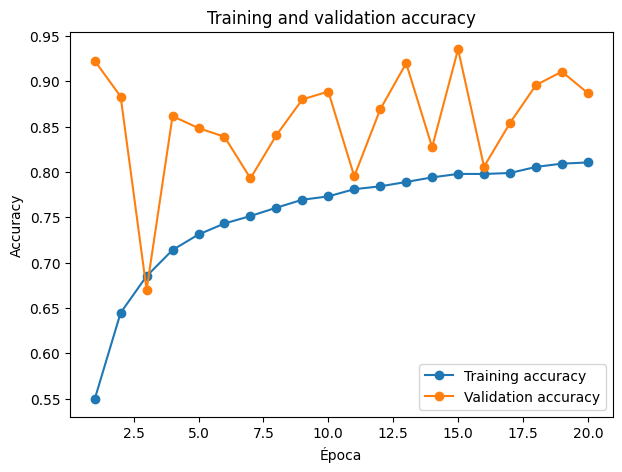

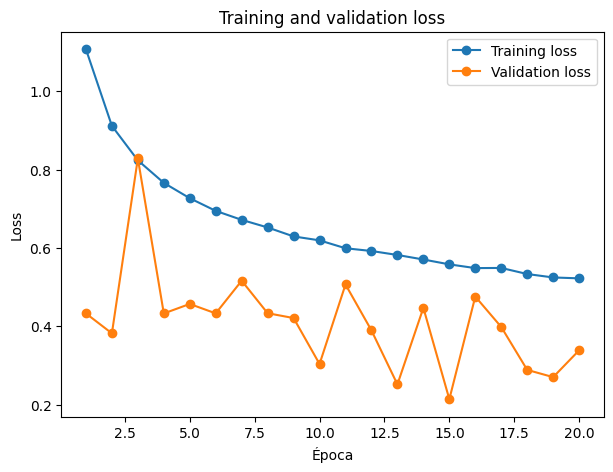

In [12]:
# =========================
# GRÁFICAS DE ENTRENAMIENTO
# =========================

acc = historial.history["accuracy"]
val_acc = historial.history["val_accuracy"]
loss = historial.history["loss"]
val_loss = historial.history["val_loss"]

epocas = range(1, len(acc) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epocas, acc, "o-", label="Training accuracy")
plt.plot(epocas, val_acc, "o-", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epocas, loss, "o-", label="Training loss")
plt.plot(epocas, val_loss, "o-", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
# =========================
# REPORTE DE CLASIFICACIÓN
# =========================

y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

predicciones_val = modelo.predict(val_ds)
y_pred = np.argmax(predicciones_val, axis=1)

print(classification_report(y_true, y_pred, target_names=clases))

254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

      Aranas       0.00      0.00      0.00         0
    Ballenas       0.00      0.00      0.00         0
     Changos       0.00      0.00      0.00         0
     Pajaros       0.02      0.60      0.04         5
       Ranas       1.00      0.89      0.94      8120

    accuracy                           0.89      8125
   macro avg       0.20      0.30      0.20      8125
weighted avg       1.00      0.89      0.94      8125



c:\Users\Fernando\OneDrive\Escritorio\VsCode Proyects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fernando\OneDrive\Escritorio\VsCode Proyects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fernando\OneDrive\Escritorio\VsCode Proyects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## Revisar aciertos y errores visualmente

Found 7207 correct labels


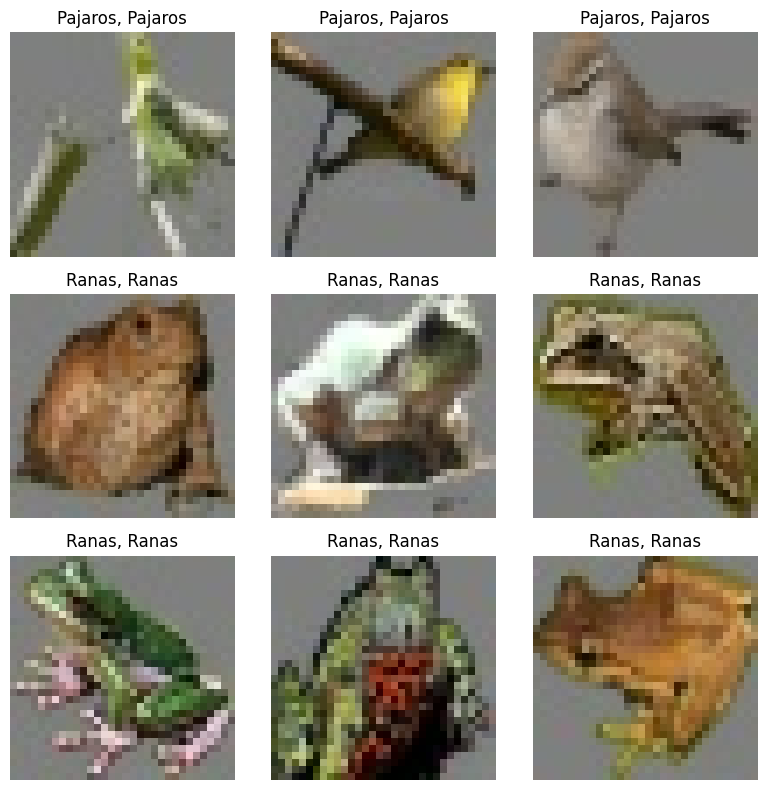

In [14]:
# =========================
# IMÁGENES CORRECTAS
# =========================

imagenes_val = np.concatenate([x.numpy() for x, y in val_ds], axis=0)

correct = np.where(y_pred == y_true)[0]
print("Found %d correct labels" % len(correct))

plt.figure(figsize=(8, 8))
for i, idx in enumerate(correct[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagenes_val[idx].astype("uint8"))
    plt.title(f"{clases[y_pred[idx]]}, {clases[y_true[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Found 918 incorrect labels


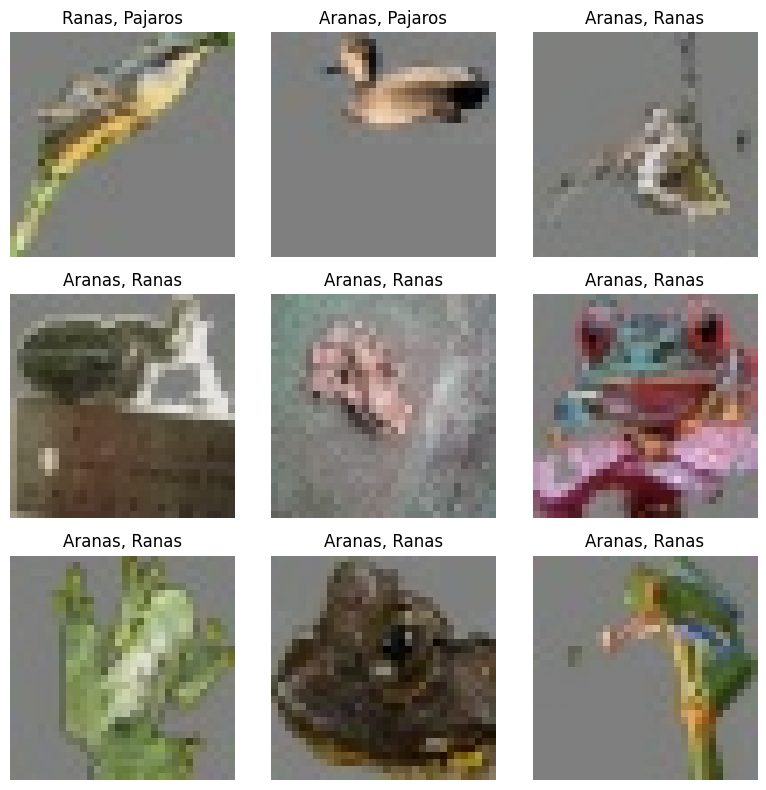

In [15]:
# =========================
# IMÁGENES INCORRECTAS
# =========================

incorrect = np.where(y_pred != y_true)[0]
print("Found %d incorrect labels" % len(incorrect))

if len(incorrect) == 0:
    print("No hubo errores en la validación interna.")
else:
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(incorrect[:9]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(imagenes_val[idx].astype("uint8"))
        plt.title(f"{clases[y_pred[idx]]}, {clases[y_true[idx]]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Probar imágenes externas desde `tests/`

In [17]:
# =========================
# PRUEBA CON IMÁGENES EXTERNAS
# =========================
# Coloca imágenes nuevas dentro de la carpeta:
# tests/
#
# Este bloque usa el mismo tamaño 32x32.
# NO divide entre 255 porque el modelo ya tiene Rescaling(1./255) internamente.

from keras.models import load_model
from keras.utils import load_img, img_to_array

modelo_cargado = load_model(modelo_path)

with open(clases_path, "r", encoding="utf-8") as f:
    clases_cargadas = json.load(f)

print("Modelo cargado exitosamente.")
print("Clases cargadas:", clases_cargadas)

images = []
filenames_found = []

for filename in os.listdir(ruta_tests):
    if filename.lower().endswith(extensiones_validas):
        filepath = os.path.join(ruta_tests, filename)

        try:
            image = load_img(filepath, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb")
            image_array = img_to_array(image)
            images.append(image_array)
            filenames_found.append(filename)
        except Exception as e:
            print(f"Error al leer/procesar {filename}. Error: {e}")

if not images:
    print("\nNo se encontraron imágenes válidas en la carpeta tests.")
else:
    test_X_externo = np.array(images, dtype="float32")

    predicciones = modelo_cargado.predict(test_X_externo)
    predicted_labels = np.argmax(predicciones, axis=1)

    print("\n--- Resultados ---")
    for i, label_index in enumerate(predicted_labels):
        porcentaje = np.max(predicciones[i]) * 100
        print(f"{filenames_found[i]} → {clases_cargadas[label_index]} ({porcentaje:.2f}%)")

    print("\n--- Resultados detallados ---")
    for i, label_index in enumerate(predicted_labels):
        print(f"\nImagen: {filenames_found[i]}")
        for clase, probabilidad in zip(clases_cargadas, predicciones[i]):
            print(f"{clase}: {probabilidad * 100:.2f}%")
        print(f"Predicción final: {clases_cargadas[label_index]}")

Modelo cargado exitosamente.
Clases cargadas: ['Aranas', 'Ballenas', 'Changos', 'Pajaros', 'Ranas']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step

--- Resultados ---
anara5.png → Aranas (99.16%)
arana1.png → Ranas (39.04%)
arana2.png → Aranas (96.44%)
arana3.png → Aranas (99.96%)
arana4.png → Aranas (100.00%)

--- Resultados detallados ---

Imagen: anara5.png
Aranas: 99.16%
Ballenas: 0.52%
Changos: 0.09%
Pajaros: 0.19%
Ranas: 0.04%
Predicción final: Aranas

Imagen: arana1.png
Aranas: 33.72%
Ballenas: 0.17%
Changos: 23.37%
Pajaros: 3.70%
Ranas: 39.04%
Predicción final: Ranas

Imagen: arana2.png
Aranas: 96.44%
Ballenas: 0.00%
Changos: 0.01%
Pajaros: 0.00%
Ranas: 3.55%
Predicción final: Aranas

Imagen: arana3.png
Aranas: 99.96%
Ballenas: 0.00%
Changos: 0.00%
Pajaros: 0.02%
Ranas: 0.01%
Predicción final: Aranas

Imagen: arana4.png
Aranas: 100.00%
Ballenas: 0.00%
Changos: 0.00%
Pajaros: 0.00%
Ranas: 0.00%
Predicción final: Aranas
